In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/global_green_energy_pulse_20260112.csv")

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (1920, 7)


,city,time,shortwave_radiation,wind_speed_100m,green_score,latitude,longitude
0,New York,2026-01-05 00:00:00,0.0,22.9,0.763333,40.71,-74.0
1,New York,2026-01-05 01:00:00,0.0,23.4,0.780000,40.71,-74.0
2,New York,2026-01-05 02:00:00,0.0,28.2,0.940000,40.71,-74.0
3,New York,2026-01-05 03:00:00,0.0,30.0,1.000000,40.71,-74.0
4,New York,2026-01-05 04:00:00,0.0,29.7,0.990000,40.71,-74.0


In [ ]:
print("\nThông tin dataset:")
df.info()


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 1920 non-null   object 
 1   time                 1920 non-null   object 
 2   shortwave_radiation  1920 non-null   float64
 3   wind_speed_100m      1920 non-null   float64
 4   green_score          1920 non-null   float64
 5   latitude             1920 non-null   float64
 6   longitude            1920 non-null   float64
dtypes: float64(5), object(2)
memory usage: 105.1+ KB


In [ ]:
print("\nSố giá trị thiếu:")
print(df.isnull().sum())


Số giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
print("--- Làm sạch dữ liệu ---")

# Chọn các biến cần dùng
df_clean = df[['shortwave_radiation', 'wind_speed_100m', 'green_score']].copy()

# Xóa missing
df_clean = df_clean.dropna()

print("Số dòng sau khi làm sạch:", df_clean.shape[0])

--- Làm sạch dữ liệu ---
Số dòng sau khi làm sạch: 1920


In [ ]:
print("--- Tạo biến phân loại ---")

# ===== 2 nhóm (Radiation) =====
median_rad = df_clean['shortwave_radiation'].median()

df_clean['radiation_level_2'] = np.where(
    df_clean['shortwave_radiation'] <= median_rad,
    'Low',
    'High'
)

# ===== 3 nhóm (Wind) =====
q1 = df_clean['wind_speed_100m'].quantile(0.33)
q2 = df_clean['wind_speed_100m'].quantile(0.66)

def classify_wind(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Medium'
    else:
        return 'High'

df_clean['wind_level_3'] = df_clean['wind_speed_100m'].apply(classify_wind)

print(df_clean[['radiation_level_2','wind_level_3']].head())

--- Tạo biến phân loại ---
  radiation_level_2 wind_level_3
0               Low       Medium
1               Low       Medium
2               Low         High
3               Low         High
4               Low         High


In [ ]:
print("==============================")
print("ANOVA: Radiation (2 nhóm)")
print("==============================")

model_2 = ols('green_score ~ C(radiation_level_2)', data=df_clean).fit()
anova_2 = sm.stats.anova_lm(model_2, typ=2)

print(anova_2)

p_value_2 = anova_2["PR(>F)"][0]
print("\nP-value:", p_value_2)

if p_value_2 < 0.05:
    print("→ Có sự khác biệt giữa 2 nhóm")
else:
    print("→ Không có sự khác biệt rõ ràng")

ANOVA: Radiation (2 nhóm)
                          sum_sq      df           F        PR(>F)
C(radiation_level_2)   48.171402     1.0  231.878224  1.618462e-49
Residual              398.453756  1918.0         NaN           NaN

P-value: 1.6184615498211507e-49
→ Có sự khác biệt giữa 2 nhóm


/tmp/ipykernel_9347/503771264.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_2 = anova_2["PR(>F)"][0]


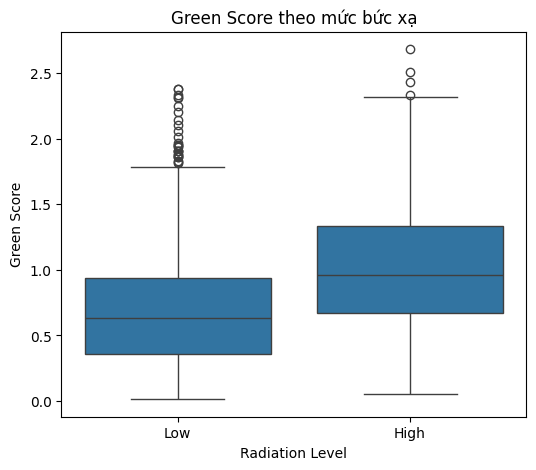

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='radiation_level_2', y='green_score', data=df_clean)

plt.title("Green Score theo mức bức xạ")
plt.xlabel("Radiation Level")
plt.ylabel("Green Score")

plt.show()

In [ ]:
print("==============================")
print("ANOVA: Wind (3 nhóm)")
print("==============================")

model_3 = ols('green_score ~ C(wind_level_3)', data=df_clean).fit()
anova_3 = sm.stats.anova_lm(model_3, typ=2)

print(anova_3)

p_value_3 = anova_3["PR(>F)"][0]
print("\nP-value:", p_value_3)

if p_value_3 < 0.05:
    print("→ Có sự khác biệt giữa các nhóm")
else:
    print("→ Không có sự khác biệt rõ ràng")

ANOVA: Wind (3 nhóm)
                     sum_sq      df            F  PR(>F)
C(wind_level_3)  256.687032     2.0  1295.340362     0.0
Residual         189.938126  1917.0          NaN     NaN

P-value: 0.0
→ Có sự khác biệt giữa các nhóm


/tmp/ipykernel_9347/4278124228.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_3 = anova_3["PR(>F)"][0]


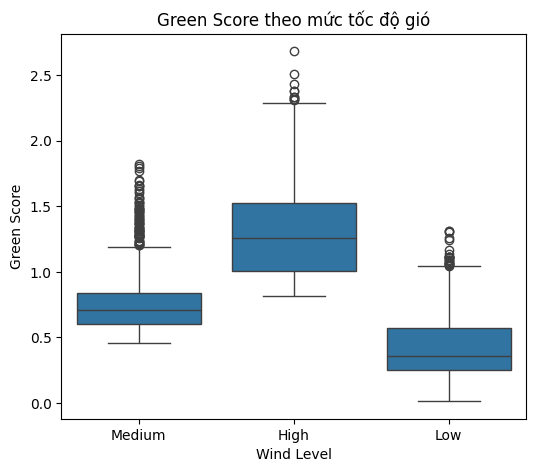

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='wind_level_3', y='green_score', data=df_clean)

plt.title("Green Score theo mức tốc độ gió")
plt.xlabel("Wind Level")
plt.ylabel("Green Score")

plt.show()

In [ ]:
print("==============================")
print("PHÂN TÍCH SÂU (TUKEY)")
print("==============================")

tukey = pairwise_tukeyhsd(
    endog=df_clean['green_score'],
    groups=df_clean['wind_level_3'],
    alpha=0.05
)

print(tukey)

PHÂN TÍCH SÂU (TUKEY)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -0.8848   0.0 -0.9259 -0.8437   True
  High Medium  -0.5329   0.0 -0.5741 -0.4916   True
   Low Medium    0.352   0.0  0.3105  0.3935   True
---------------------------------------------------


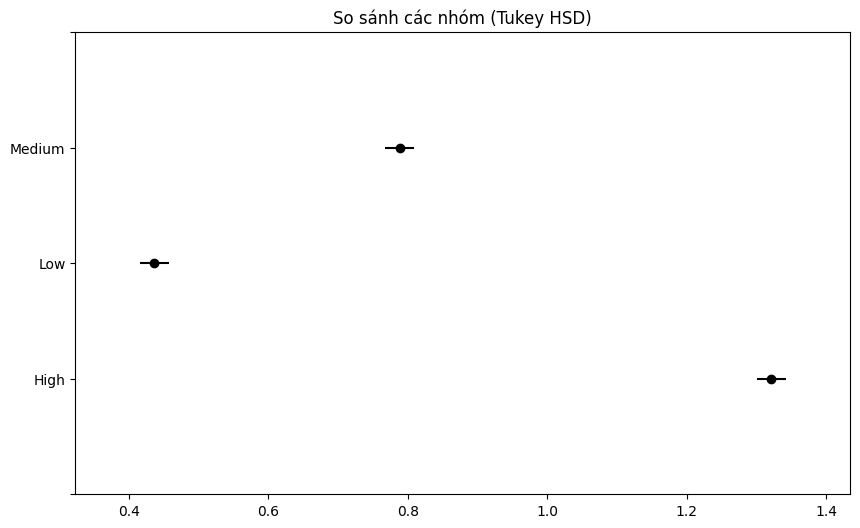

In [ ]:
tukey.plot_simultaneous()
plt.title("So sánh các nhóm (Tukey HSD)")
plt.show()

In [ ]:
print("==============================")
print("BÁO CÁO TÓM TẮT")
print("==============================")

print("\n1. Radiation (2 nhóm):")
if p_value_2 < 0.05:
    print("→ Có ảnh hưởng đến green_score")
else:
    print("→ Không có ảnh hưởng rõ ràng")

print("\n2. Wind (3 nhóm):")
if p_value_3 < 0.05:
    print("→ Có sự khác biệt giữa các nhóm gió")
else:
    print("→ Không có sự khác biệt rõ ràng")

print("\n3. Phân tích sâu:")
print("→ Xem bảng Tukey để xác định nhóm khác biệt cụ thể")

BÁO CÁO TÓM TẮT

1. Radiation (2 nhóm):
→ Có ảnh hưởng đến green_score

2. Wind (3 nhóm):
→ Có sự khác biệt giữa các nhóm gió

3. Phân tích sâu:
→ Xem bảng Tukey để xác định nhóm khác biệt cụ thể
